In [1]:
import pandas as pd

from src.training.unsupervised import find_optimal_k, train_kmeans, train_dbscan, train_gmm
from src.training.evaluation import evaluate_clustering
from src.training.visualization import plot_cluster_profiles, plot_cluster_scatter_2d, plot_categorical_profiling_heatmap

pd.set_option('display.max_columns', None)
df_ml = pd.read_parquet("data/prepared/ted_prepared.parquet")

In [2]:
# ------------------------------------------------------------------------------
# STEP 1: Methodological Level Extraction and Feature Setup
# ------------------------------------------------------------------------------

# The unit of analysis is the procurement procedure (Notice), not the individual contract (Lot).
# Keeping multiple lots per notice would create an overrepresentation bias, where highly 
# fragmented projects form artificial density clusters. 
df_notice = df_ml.drop_duplicates(subset=['ID_NOTICE']).copy()
print(f"Dataset reduced to unique notices: {len(df_notice)} rows.")

# Categorical features are excluded from the mathematical clustering to avoid 
# the curse of dimensionality, but retained in the dataframe for post-hoc profiling.
categorical_cols_for_profiling = ['ISO_COUNTRY_CODE', 'CAE_TYPE', 'TOP_TYPE', 'CPV', 'TYPE_OF_CONTRACT', 'CRIT_CODE']

# Structural features represent the macro-strategy of the buyer and the market response.
# Notice-level features are strictly required to match the unit of analysis.
numeric_cols_for_clustering = [
    'TARGET_AWARD_VALUE_EUR',
    'LOTS_NUMBER',
    'PREPARATION_DAYS',
    'NUTS_REGION_COUNT',
    'NUMBER_OF_TENDERS'
]

# Extracting the clustering subset. Missing values will be imputed by the pipeline.
df_cluster = df_notice[numeric_cols_for_clustering + categorical_cols_for_profiling].copy()

# best_k = find_optimal_k(df_cluster, categorical_cols=[], numeric_cols=numeric_cols_for_clustering, max_k=6)
# Note: Empirical tests showed k=2 yields the highest silhouette score by splitting 
# standard procedures from extreme outliers. However, k=4 is selected manually in the 
# modeling phase to extract more nuanced economic archetypes.

Dataset reduced to unique notices: 633267 rows.



--- Clustering Metrics ---
Silhouette Score:      0.3601 (Higher is better, max 1)
Davies-Bouldin Index:  1.1521 (Lower is better, min 0)
Calinski-Harabasz:     29,301.6 (Higher is better)

--- 1. STRUCTURAL PROFILING ---


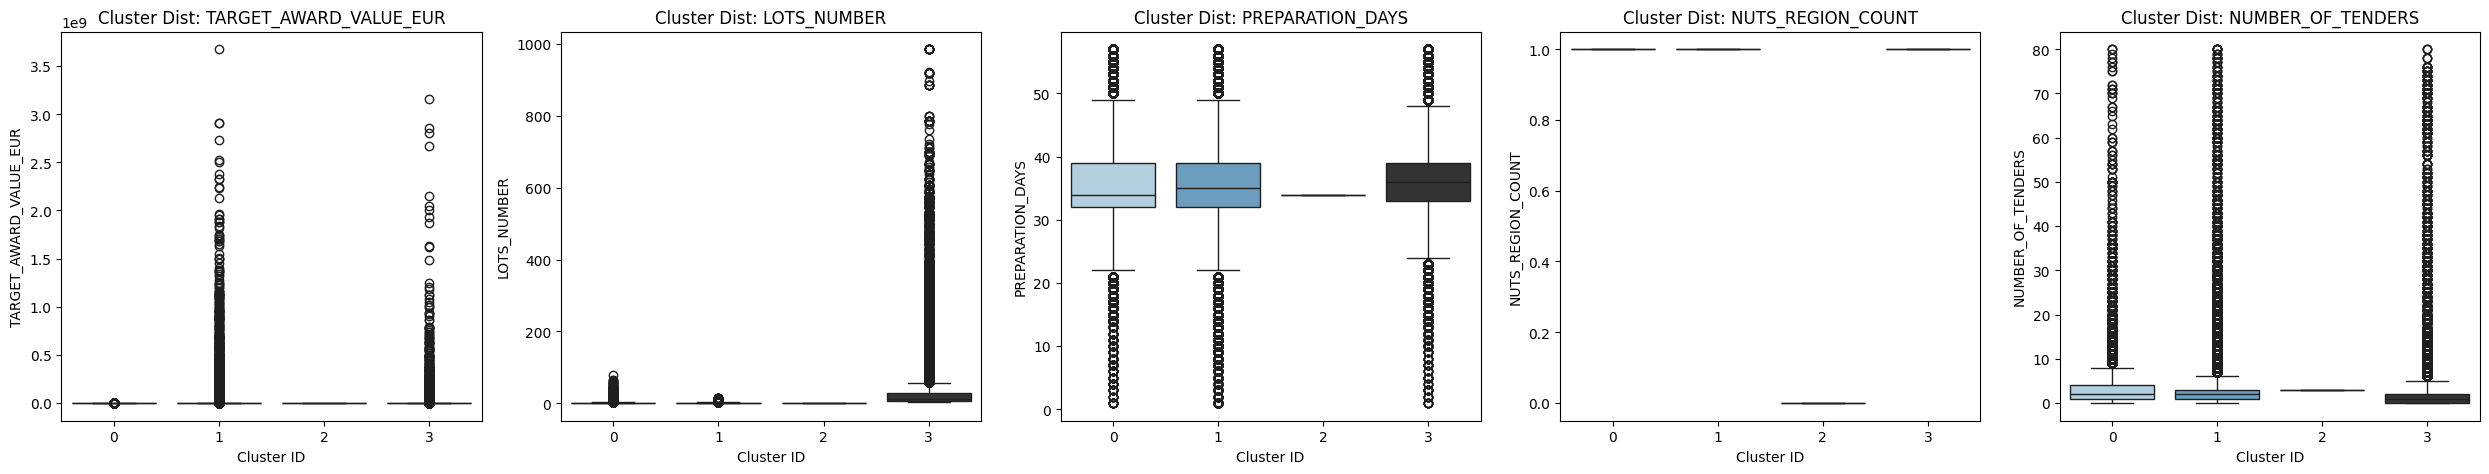


--- 2. POST-HOC PROFILING ---


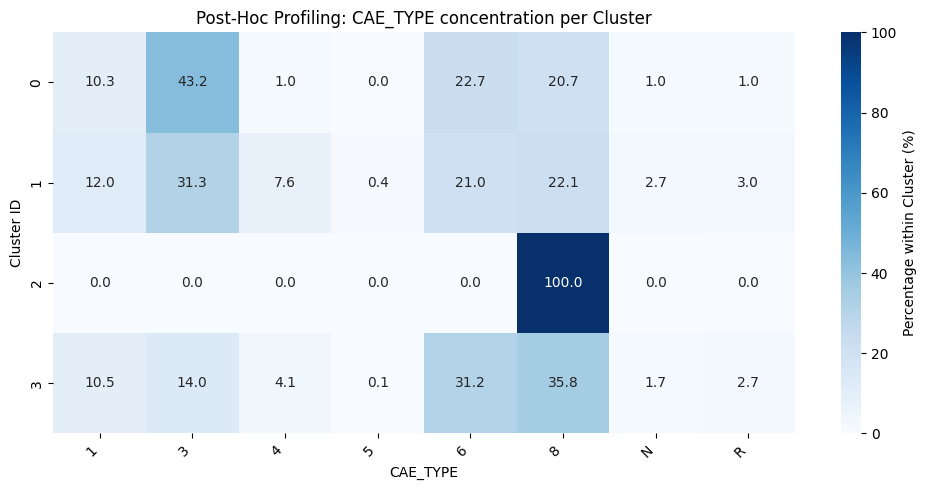

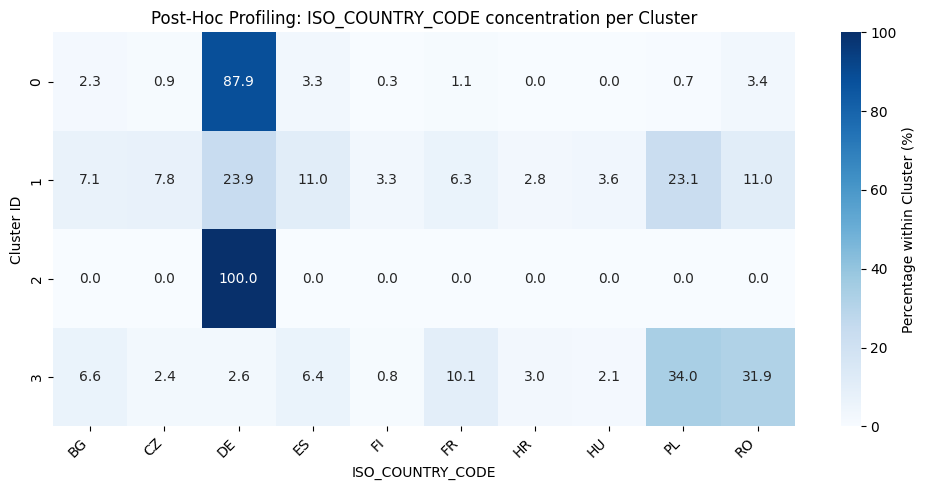


--- 3. TOPOLOGICAL PROJECTION ---


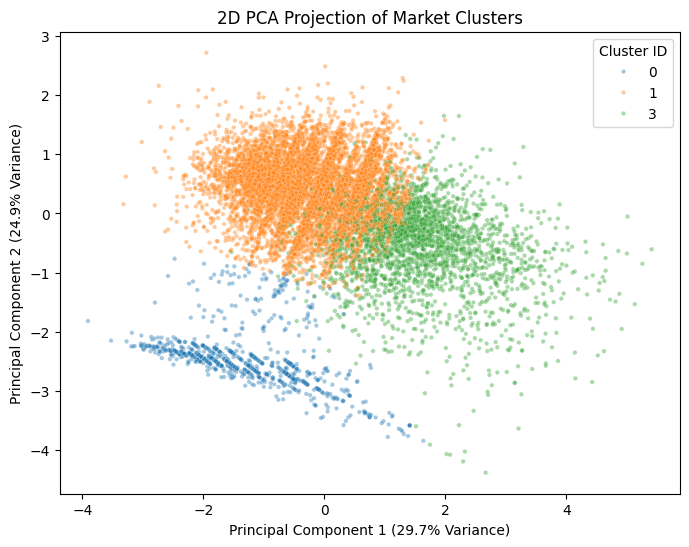

In [3]:
# ------------------------------------------------------------------------------
# STEP 2: K-Means Clustering (Market Segmentation)
# ------------------------------------------------------------------------------

df_km, labels_km, X_proc_km, _ = train_kmeans(
    df=df_cluster, 
    categorical_cols=[], 
    numeric_cols=numeric_cols_for_clustering, 
    n_clusters=4, 
    n_init=15
)

evaluate_clustering(X_proc_km, labels_km, sample_size=100000)
df_km['CLUSTER'] = labels_km

print("\n--- 1. STRUCTURAL PROFILING ---")
# Boxplots reveal the underlying feature distributions defining each segment.
plot_cluster_profiles(df_km, 'CLUSTER', numeric_cols_for_clustering)

print("\n--- 2. POST-HOC PROFILING ---")
# Heatmaps indicate whether specific segments are dominated by certain regions or sectors.
plot_categorical_profiling_heatmap(df_km, 'CLUSTER', 'CAE_TYPE', top_n=8)
plot_categorical_profiling_heatmap(df_km, 'CLUSTER', 'ISO_COUNTRY_CODE', top_n=10)

print("\n--- 3. TOPOLOGICAL PROJECTION ---")
# Dimensionality reduction (PCA) is used to plot the multidimensional space in 2D.
# This visualizes whether the segments form distinct, separated islands or a continuous spectrum.
plot_cluster_scatter_2d(X_proc_km, labels_km, vis_sample_size=15000, point_alpha=0.4, point_size=10)


--- Clustering Metrics ---
Silhouette Score:      0.1147 (Higher is better, max 1)
Davies-Bouldin Index:  2.6231 (Lower is better, min 0)
Calinski-Harabasz:     2,891.3 (Higher is better)


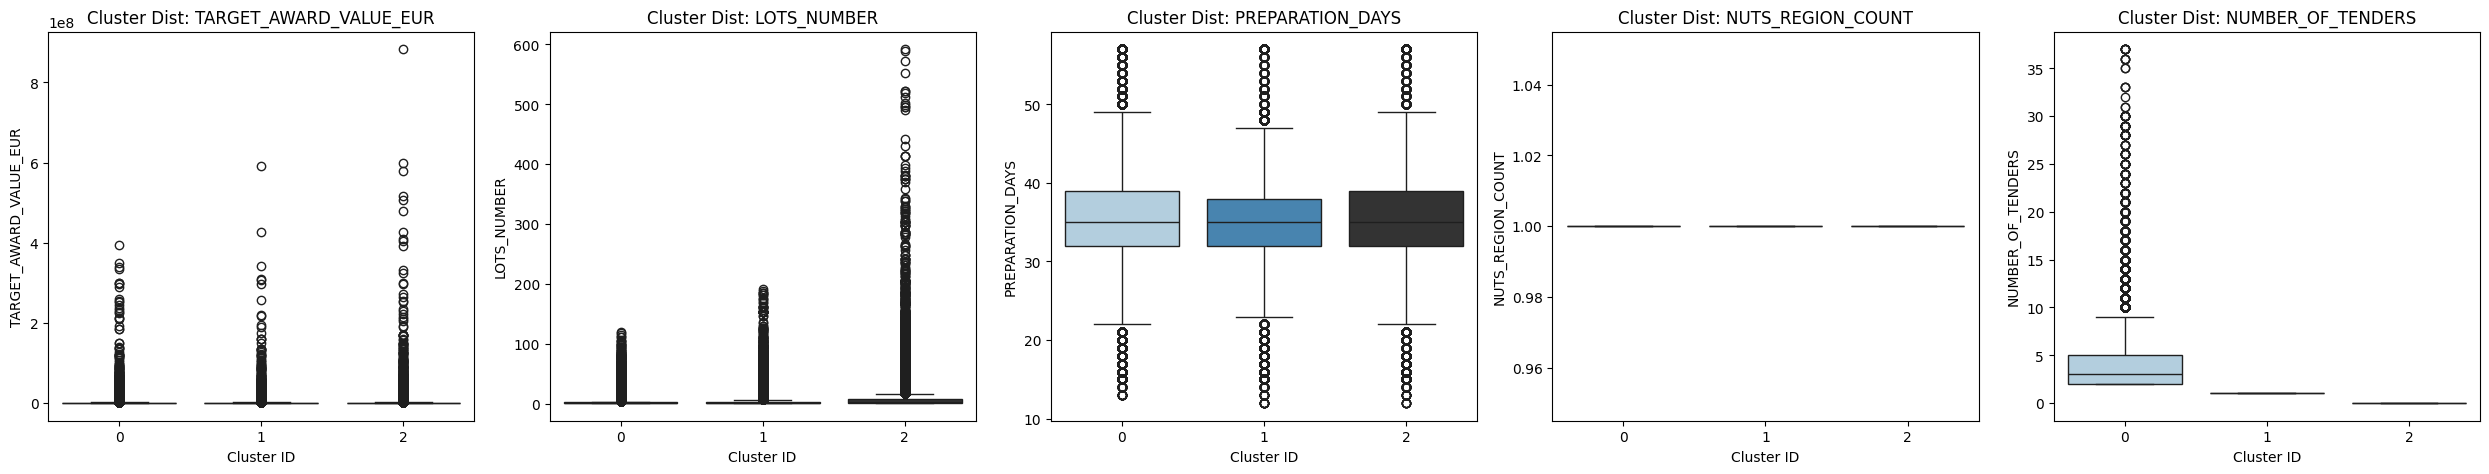

In [4]:
# ------------------------------------------------------------------------------
# STEP 3: DBSCAN Clustering (Outlier Detection)
# ------------------------------------------------------------------------------

df_db, labels_db, X_proc_db, _ = train_dbscan(
    df=df_cluster, 
    categorical_cols=[], 
    numeric_cols=numeric_cols_for_clustering, 
    eps=0.5,
    min_samples=30, 
    max_rows=100000 
)

evaluate_clustering(X_proc_db, labels_db)
df_db['CLUSTER'] = labels_db

if len(set(labels_db)) > 1:
    plot_cluster_profiles(df_db[df_db['CLUSTER'] != -1], 'CLUSTER', numeric_cols_for_clustering)


--- Clustering Metrics ---
Silhouette Score:      0.1406 (Higher is better, max 1)
Davies-Bouldin Index:  2.1458 (Lower is better, min 0)
Calinski-Harabasz:     19,117.4 (Higher is better)


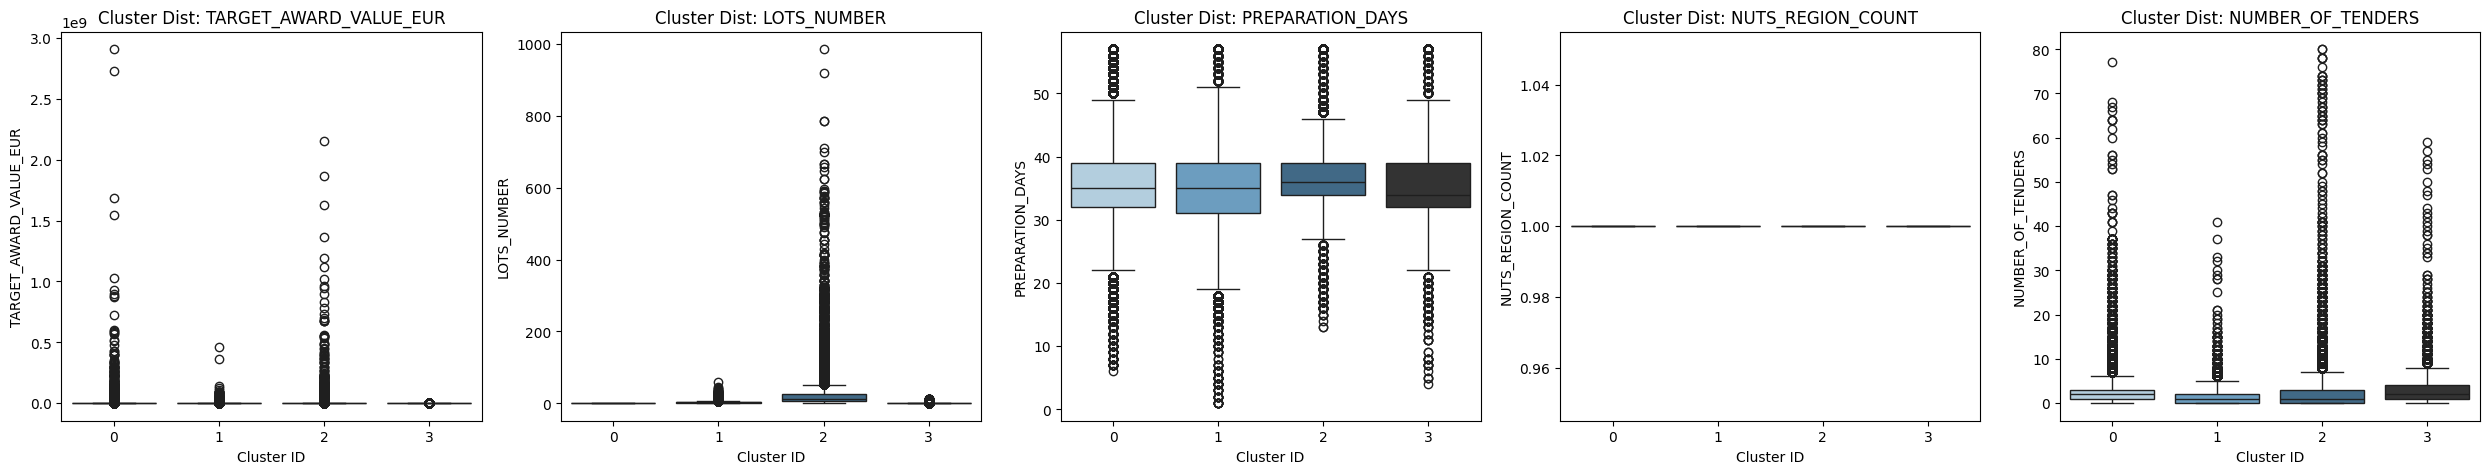

In [5]:
# ------------------------------------------------------------------------------
# STEP 4: Gaussian Mixture Model (Probabilistic Clustering)
# ------------------------------------------------------------------------------

df_gmm, labels_gmm, X_proc_gmm, _ = train_gmm(
    df=df_cluster, 
    categorical_cols=[], 
    numeric_cols=numeric_cols_for_clustering, 
    n_clusters=4,
    covariance_type='full', 
    n_init=3,
    max_rows=100000 
)

evaluate_clustering(X_proc_gmm, labels_gmm, sample_size=100000)
df_gmm['CLUSTER'] = labels_gmm
plot_cluster_profiles(df_gmm, 'CLUSTER', numeric_cols_for_clustering)